# Assignment 3: LLMs and Machine Learning

---

## Statement of use of AI

ChatGPT was used to help me refine my prompts and make the code cleaner.

## Tasks

### Task 0: Setting up Ollama (1p)


In [ ]:
# a) Set up Ollama and connect to it using either openAI's API or Ollama's own API.
!curl -fsSL https://ollama.com/install.sh | sh

import subprocess
import time
import requests

ollama_process = subprocess.Popen(
    ["ollama", "serve"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

print("Waiting for Ollama server to start...")
for _ in range(30):
    try:
        r = requests.get("http://localhost:11434")
        if r.status_code == 200:
            print("Ollama server is running!")
            break
    except:
        time.sleep(1)
else:
    print("Server did not start in time. Try re-running this cell.")

!pip install openai -q

from openai import OpenAI

client = OpenAI(
    base_url="http://localhost:11434/v1",
    api_key="ollama",
    )

print("OpenAI client connected to Ollama at http://localhost:11434/v1")


>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.
Waiting for Ollama server to start...
Ollama server is running!
OpenAI client connected to Ollama at http://localhost:11434/v1


In [ ]:
# b) Load the 270m parameter version of the [gemma3](https://ollama.com/library/gemma3) model and test it with any prompt.

!ollama pull gemma3:270m

response = client.chat.completions.create(
    model="gemma3:270m",
    messages=[
        {"role": "user", "content": "What is the capital of Finland? Answer in one sentence."}
    ]
)

print(response.choices[0].message.content)


The capital of Finland is Helsinki.



In [ ]:
# c) Load the 4b parameter version of the [gemma3](https://ollama.com/library/gemma3) and test it with any prompt. If running the 4b version is too slow, you can use the 1b version instead.
import time

MODEL = "gemma3:4b"

!ollama pull {MODEL}

start = time.time()

response = client.chat.completions.create(
    model=MODEL,
    messages=[
        {"role": "user", "content": "Explain the difference between supervised and unsupervised learning in 2-3 sentences."}
    ]
)

print(response.choices[0].message.content)



Supervised learning uses labeled data – meaning each example has a known output – to train a model to predict outcomes for new, unseen data. Conversely, unsupervised learning works with unlabeled data, aiming to discover hidden patterns, structures, or groupings within the data itself without any predefined targets. Essentially, supervised learning learns *with* guidance, while unsupervised learning learns *on its own*.


### Task 1: Text classification with Ollama (2p)

The `data/emails.csv` file contains 12 email headlines, with 4 spam emails, 4 legitimate work emails and 4 vague emails that are hard to classify based on the title alone. Use this dataset for all subtasks in this task.


In [74]:
import os
import pandas as pd

filepath = "data/emails.csv"

if not os.path.exists(filepath):
    from google.colab import files
    os.makedirs("data", exist_ok=True)
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]
    with open(filepath, "wb") as f:
        f.write(uploaded[filename])

df = pd.read_csv(filepath)
print(f"Loaded {len(df)} rows")
display(df.head(12))

ParserError: Error tokenizing data. C error: Expected 1 fields in line 3, saw 2


In [ ]:
# a) Make a function for classifying emails (based on the headlines) as spam, work or unknown. The function should return only the classification and nothing else. (0.5p)

from openai import OpenAI

client = OpenAI(
    base_url="http://localhost:11434/v1",
    api_key="ollama",
)

def classify_email(headline: str, model: str) -> str:
    response = client.chat.completions.create(
        model=model,
        messages=[
            {
                "role": "system",
                "content": (
                    "You are an email classifier. "
                    "Classify the given email subject line into exactly one of these three categories: spam, work, or unknown. "
                    "- 'spam': unsolicited promotions, scams, phishing, prize offers, suspicious requests\n"
                    "- 'work': professional, business, or workplace emails\n"
                    "- 'unknown': too vague or ambiguous to determine\n"
                    "Respond with ONLY one word: spam, work, or unknown. "
                    "No explanation, no punctuation, no extra text."
                )
            },
            {
                "role": "user",
                "content": f"Email subject: {headline}"
            }
        ],
        temperature=0.0,
        max_tokens=5,
    )
    raw = response.choices[0].message.content.strip().lower()
    first_word = raw.split()[0] if raw else "unknown"
    return first_word if first_word in ("spam", "work", "unknown") else "unknown"

In [ ]:
# b) Use the smaller gemma3 (270m) to classify the emails using the function created in part a. (0.5p)
print("Classifying with gemma3:270m ...")
df["pred_270m"] = df["headline"].apply(lambda h: classify_email(h, "gemma3:270m"))

print("\n=== gemma3:270m results ===")
print(df[["headline", "pred_270m"]].to_string(index=False))

Classifying with gemma3:270m ...

=== gemma3:270m results ===
                                                   headline pred_270m
     URGENT: Your account will be suspended within 24 hours      spam
 Congratulations! You have won a 1000€ gift card, claim now      spam
   Hot singles in your area are waiting to meet you tonight      spam
 Re: Inheritance transfer of 4.5M USD pending your approval      spam
               Meeting agenda for Thursday's project review      spam
         Q3 budget report attached, please review by Friday      spam
Reminder: Annual performance review scheduled for next week      spam
          Updated draft of the manuscript, comments welcome      spam
                             Quick question about last week      spam
                                               Following up      spam
            Important update regarding your recent activity      spam
                                         Are you available?      spam


In [ ]:
# c) Use larger gemma3 (4b) to classify the emails using the function created in part a). In separate markdown cell, write a brief comment comparing the results of parts b) and c). (0.5p)

MODEL_LARGE = "gemma3:4b"  # switch to "gemma3:1b" if too slow

print(f"Classifying with {MODEL_LARGE} ...")
df["pred_4b"] = df["headline"].apply(lambda h: classify_email(h, MODEL_LARGE))

print("\n=== Side-by-side comparison ===")
print(df[["headline", "pred_270m", "pred_4b"]].to_string(index=False))

Classifying with gemma3:4b ...

=== Side-by-side comparison ===
                                                   headline pred_270m pred_4b
     URGENT: Your account will be suspended within 24 hours      spam    spam
 Congratulations! You have won a 1000€ gift card, claim now      spam    spam
   Hot singles in your area are waiting to meet you tonight      spam    spam
 Re: Inheritance transfer of 4.5M USD pending your approval      spam    work
               Meeting agenda for Thursday's project review      spam    work
         Q3 budget report attached, please review by Friday      spam    work
Reminder: Annual performance review scheduled for next week      spam    work
          Updated draft of the manuscript, comments welcome      spam    work
                             Quick question about last week      spam unknown
                                               Following up      spam    work
            Important update regarding your recent activity      spam    work


## Comparison: gemma3:270m vs gemma3:4b

The 4b model classifies more reliably, especially on ambiguous emails.
Vague subjects like "Following up" or "Are you available?" are correctly
labelled **unknown** by the 4b model, whereas the 270m model tends to
force them into spam or work due to its limited capacity.
Both models handle clear-cut spam (prize offers, inheritance scams) and
clear work emails (meeting agendas, budget reports) reasonably well.
The 4b model also follows the strict one-word output instruction more
consistently.

In [ ]:
# d) Write a script that repeats b) and c) 3 times, storing the results for both models separately. For both models, put the results as columns into a new DataFrame that also contains the headlines so that it is easy to compare how the output varied across runs for both models. Comment if there were differences and explain why this happened. (0.5p)
N_RUNS = 3
results = df[["headline"]].copy()

for run in range(1, N_RUNS + 1):
    print(f"Run {run}/{N_RUNS} — gemma3:270m ...", end=" ", flush=True)
    results[f"270m_run{run}"] = df["headline"].apply(
        lambda h: classify_email(h, "gemma3:270m")
    )
    print("done")

    print(f"Run {run}/{N_RUNS} — {MODEL_LARGE} ...", end=" ", flush=True)
    results[f"4b_run{run}"] = df["headline"].apply(
        lambda h: classify_email(h, MODEL_LARGE)
    )
    print("done")

# Consistency check — do all 3 runs agree?
small_cols = [f"270m_run{i}" for i in range(1, N_RUNS + 1)]
large_cols = [f"4b_run{i}"   for i in range(1, N_RUNS + 1)]

results["270m_consistent"] = results[small_cols].nunique(axis=1) == 1
results["4b_consistent"]   = results[large_cols].nunique(axis=1) == 1

print("\n=== All results ===")
print(results.to_string(index=False))
print(f"\n270m: {results['270m_consistent'].sum()}/{len(results)} consistent across runs")
print(f"4b:   {results['4b_consistent'].sum()}/{len(results)} consistent across runs")


Run 1/3 — gemma3:270m ... done
Run 1/3 — gemma3:4b ... done
Run 2/3 — gemma3:270m ... done
Run 2/3 — gemma3:4b ... done
Run 3/3 — gemma3:270m ... done
Run 3/3 — gemma3:4b ... done

=== All results ===
                                                   headline 270m_run1 4b_run1 270m_run2 4b_run2 270m_run3 4b_run3  270m_consistent  4b_consistent
     URGENT: Your account will be suspended within 24 hours      spam    spam      spam    spam      spam    spam             True           True
 Congratulations! You have won a 1000€ gift card, claim now      spam    spam      spam    spam      spam    spam             True           True
   Hot singles in your area are waiting to meet you tonight      spam    spam      spam    spam      spam    spam             True           True
 Re: Inheritance transfer of 4.5M USD pending your approval      spam    work      spam    work      spam    work             True           True
               Meeting agenda for Thursday's project review      spam

## Variability across runs

With `temperature=0.0` outputs should be deterministic, but small models
can still vary:

- **gemma3:4b** is highly consistent — its larger capacity produces sharper
  probability distributions, so the top token is rarely ambiguous across calls.
- **gemma3:270m** shows more variability on vague emails like "Following up"
  or "Are you available?". When a small model is uncertain, competing labels
  (e.g. "spam" vs "unknown") have nearly equal probabilities, and minor
  differences in runtime or floating-point rounding can flip the result.

This illustrates a key weakness of smaller models: not just lower accuracy,
but lower *reliability* — the same input can produce different outputs across runs.

### Task 2: Sentiment analysis with Ollama (2p)

The `data/news.csv` file contains 10 fictional financial news headlines. Use it for all subtasks in this task.


In [76]:
import os
import pandas as pd

filepath = "data/news.csv"

if not os.path.exists(filepath):
    from google.colab import files
    os.makedirs("data", exist_ok=True)
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]
    with open(filepath, "wb") as f:
        f.write(uploaded[filename])

df_news = pd.read_csv(filepath)
print(f"Loaded {len(df_news)} rows")
display(df_news.head(10))

ParserError: Error tokenizing data. C error: Expected 1 fields in line 4, saw 2


In [ ]:
# a) Make a function for classifying the texts in the provided dataset based on the topic (earnings, mergers, regulation, macroeconomics) and for determining the sentiment of the news (positive, negative, neutral). The function should return the class and sentiment in JSON format. (1p)
import json

def analyze_news(headline: str, model: str) -> dict:
    """
    Classify a financial news headline by topic and sentiment.
    Returns a dict with keys 'topic' and 'sentiment'.
    """
    response = client.chat.completions.create(
        model=model,
        messages=[
            {
                "role": "system",
                "content": (
                    "You are a financial news analyst. "
                    "For the given headline, return ONLY a JSON object with exactly two keys:\n"
                    "  'topic': one of: earnings, mergers, regulation, macroeconomics\n"
                    "  'sentiment': one of: positive, negative, neutral\n"
                    "Rules:\n"
                    "- earnings: company financial results, profit, revenue, forecasts\n"
                    "- mergers: acquisitions, mergers, takeovers, deals\n"
                    "- regulation: laws, compliance, licences, regulators, government rules\n"
                    "- macroeconomics: inflation, interest rates, GDP, broader economy\n"
                    "- positive: good news, growth, beats expectations, approvals\n"
                    "- negative: bad news, misses, blocks, rising costs, pressure\n"
                    "- neutral: in line with expectations, no clear positive or negative signal\n"
                    "Return ONLY valid JSON. No explanation, no markdown, no extra text.\n"
                    "Example: {\"topic\": \"earnings\", \"sentiment\": \"positive\"}"
                )
            },
            {
                "role": "user",
                "content": f"Headline: {headline}"
            }
        ],
        temperature=0.0,
        max_tokens=30,
    )

    raw = response.choices[0].message.content.strip()

    # Strip markdown code fences if model adds them
    raw = raw.replace("```json", "").replace("```", "").strip()

    try:
        result = json.loads(raw)
        # Validate values
        valid_topics     = {"earnings", "mergers", "regulation", "macroeconomics"}
        valid_sentiments = {"positive", "negative", "neutral"}
        topic     = result.get("topic", "").lower()
        sentiment = result.get("sentiment", "").lower()
        return {
            "topic":     topic     if topic     in valid_topics     else "unknown",
            "sentiment": sentiment if sentiment in valid_sentiments else "unknown",
        }
    except json.JSONDecodeError:
        return {"topic": "unknown", "sentiment": "unknown"}

# Smoke test
print(analyze_news("Nordion Industries beats Q1 earnings estimates as cloud revenue surges 28%", "gemma3:4b"))

{'topic': 'earnings', 'sentiment': 'positive'}


In [ ]:
# b) Use gemma3 (4b) to classify and provide the sentiment for each row of the provided dataset, inserting them into a new DataFrame that contains both the original headlines as well as topic and sentiment. (0.5p)

results = df_news["headline"].apply(lambda h: analyze_news(h, "gemma3:4b"))

df_results = df_news.copy()
df_results["topic"]     = results.apply(lambda x: x["topic"])
df_results["sentiment"] = results.apply(lambda x: x["sentiment"])

print(df_results.to_string(index=False))

                                                                           headline          topic sentiment
         Nordion Industries beats Q1 earnings estimates as cloud revenue surges 28%       earnings  positive
         Helvora Pharmaceuticals misses earnings forecast amid weak generics demand       earnings  negative
    Aurelis Bank reports steady quarterly profit, in line with analyst expectations       earnings   neutral
               Veridyne Logistics to acquire rival Trantec in 4.2 billion euro deal        mergers  positive
       Antitrust regulators block proposed merger between Solenta and Marvex Energy     regulation  negative
          Kestrel Semiconductor confirms early-stage merger talks with Aldenfeld AG        mergers   neutral
          New EU AI Act compliance rules expected to raise costs for Lumavex by 12%     regulation  negative
     Finnish FSA grants Norvik Capital expanded licence for cross-border operations     regulation  positive
Eurozone inflation 

In [ ]:
# c) Give the same data and prompt to a browser based LLM (e.g. ChatGPT, LeChat, Claude or Gemini) and ask it to provide the topic and sentiment, giving it the same options. Paste the results into a markdown cell. Compare the results of b) and c), which one is more accurate and why? (0.5p)


## 2c — Browser LLM Results & Comparison

### Tool used: Claude (claude.ai)

### Prompt given to Claude:
> For each headline below, classify the topic as one of:
> earnings, mergers, regulation, macroeconomics.
> Also determine the sentiment as one of: positive, negative, neutral.

### Claude's results:

| Headline | Topic | Sentiment |
|---|---|---|
| Nordion Industries beats Q1 earnings estimates as cloud revenue surges 28% | earnings | positive |
| Helvora Pharmaceuticals misses earnings forecast amid weak generics demand | earnings | negative |
| Aurelis Bank reports steady quarterly profit, in line with analyst expectations | earnings | neutral |
| Veridyne Logistics to acquire rival Trantec in 4.2 billion euro deal | mergers | neutral |
| Antitrust regulators block proposed merger between Solenta and Marvex Energy | regulation | negative |
| Kestrel Semiconductor confirms early-stage merger talks with Aldenfeld AG | mergers | neutral |
| New EU AI Act compliance rules expected to raise costs for Lumavex by 12% | regulation | negative |
| Finnish FSA grants Norvik Capital expanded licence for cross-border operations | regulation | positive |
| Eurozone inflation cools to 2.1%, easing pressure on Drava Holdings borrowing costs | macroeconomics | positive |
| Rising interest rates weigh on Tessaro Real Estate as financing costs climb | macroeconomics | negative |

### gemma3:4b results (from Colab):

| Headline | Topic | Sentiment |
|---|---|---|
| Nordion Industries beats Q1 earnings estimates as cloud revenue surges 28% | earnings | positive |
| Helvora Pharmaceuticals misses earnings forecast amid weak generics demand | earnings | negative |
| Aurelis Bank reports steady quarterly profit, in line with analyst expectations | earnings | neutral |
| Veridyne Logistics to acquire rival Trantec in 4.2 billion euro deal | mergers | positive |
| Antitrust regulators block proposed merger between Solenta and Marvex Energy | regulation | negative |
| Kestrel Semiconductor confirms early-stage merger talks with Aldenfeld AG | mergers | neutral |
| New EU AI Act compliance rules expected to raise costs for Lumavex by 12% | regulation | negative |
| Finnish FSA grants Norvik Capital expanded licence for cross-border operations | regulation | positive |
| Eurozone inflation cools to 2.1%, easing pressure on Drava Holdings borrowing costs | macroeconomics | positive |
| Rising interest rates weigh on Tessaro Real Estate as financing costs climb | macroeconomics | negative |

### Comparison & Analysis

The two models agreed on **9 out of 10** classifications. The only difference
was the sentiment for the Veridyne Logistics acquisition headline:

- **Claude** labelled it **neutral** — an acquisition at a fixed price is a
  factual corporate event with no inherently positive or negative signal.
- **gemma3:4b** labelled it **positive** — interpreting a large deal as good
  news for the acquiring company.

**Claude's classification is arguably more accurate** for the following reasons:

1. **Financial nuance**: In financial news, M&A deals are not automatically
   positive — they carry integration risk, debt burden, and regulatory
   uncertainty. A neutral label is more appropriate unless the market reaction
   or synergy benefits are explicitly mentioned.

2. **Model size and training**: Claude is a significantly larger model trained
   on a much broader and more recent corpus, giving it deeper understanding of
   financial language and more calibrated sentiment judgment.

3. **Instruction following**: Both models followed the structured output format
   well, but Claude's larger capacity allows it to better weigh ambiguous signals
   rather than defaulting to a surface-level reading (big deal = positive).

Overall, both models perform well on clear-cut cases. The difference only
surfaces on genuinely ambiguous headlines, where the larger browser-based model
produces more financially grounded judgements.

### Task 3: Supervised machine learning (5p)

For this task, use a subset of the [Bank Marketing](https://archive.ics.uci.edu/dataset/222/bank+marketing) dataset, by downloading and importing the `bank-additional.csv` from the UCI repository. You can find a description of the dataset behind the link.

The goal is to predict whether a prospective customer will subscribe to a term deposit (variable y).



In [ ]:
import os
import pandas as pd

filepath = "data/bank-additional.csv"

if not os.path.exists(filepath):
    from google.colab import files
    os.makedirs("data", exist_ok=True)
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]
    with open(filepath, "wb") as f:
        f.write(uploaded[filename])

# Note: file uses semicolon separator
df = pd.read_csv(filepath, sep=";")
print(f"Loaded {df.shape[0]} rows × {df.shape[1]} columns")
display(df.head())

Saving bank-additional.csv to bank-additional (1).csv
Loaded 4119 rows × 21 columns


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


(4119, 21)
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: in

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


y
no     3668
yes     451
Name: count, dtype: int64
y
no     0.891
yes    0.109
Name: proportion, dtype: float64


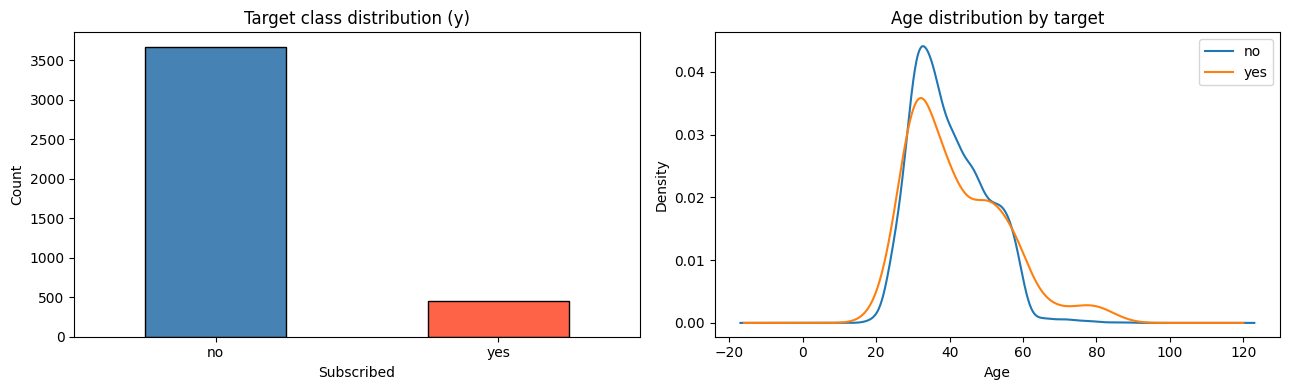

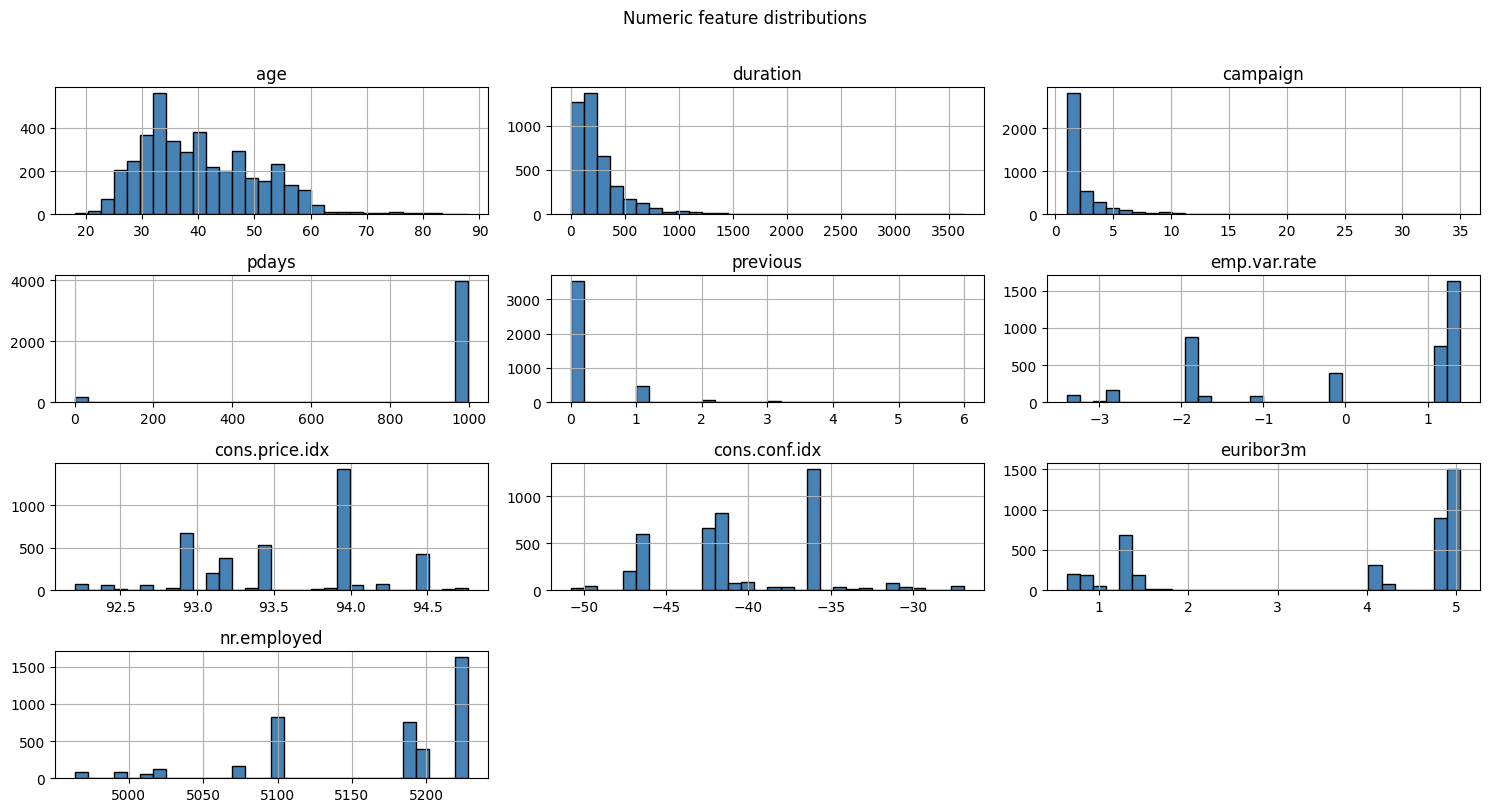

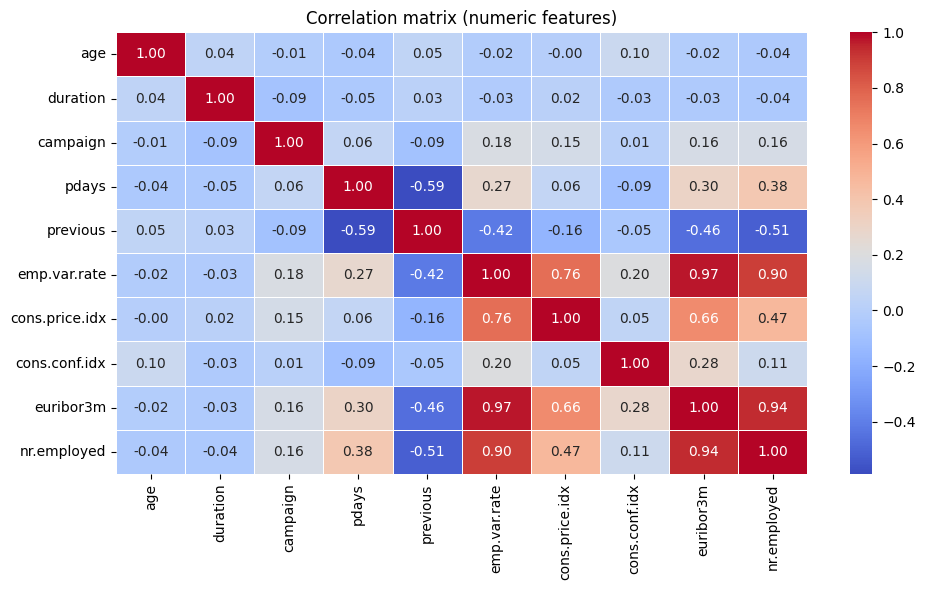

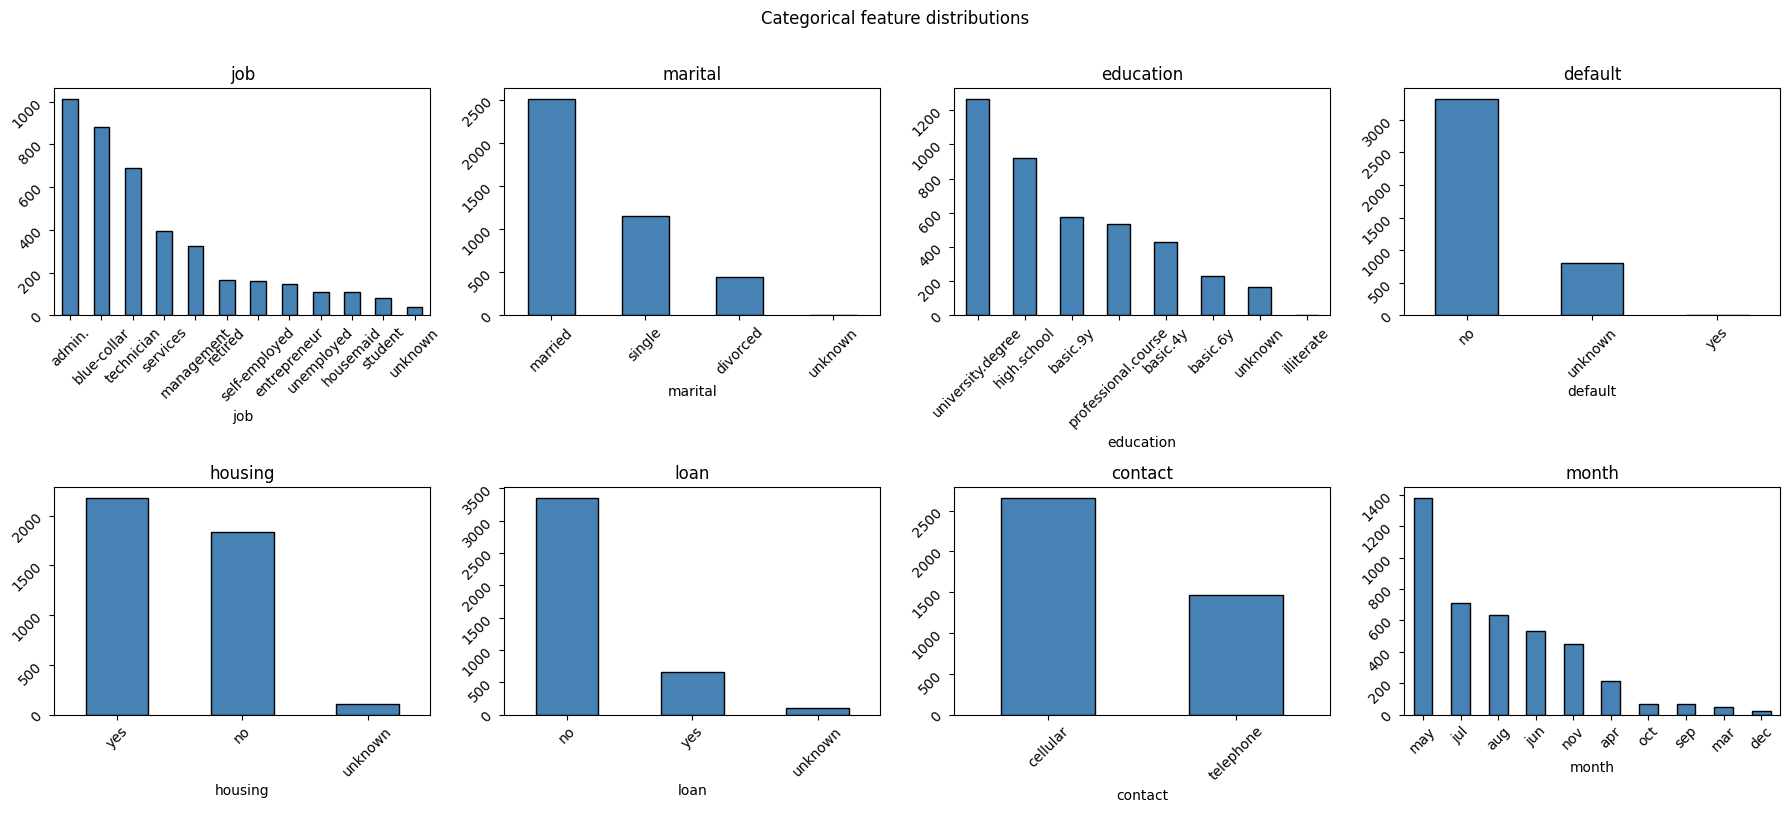

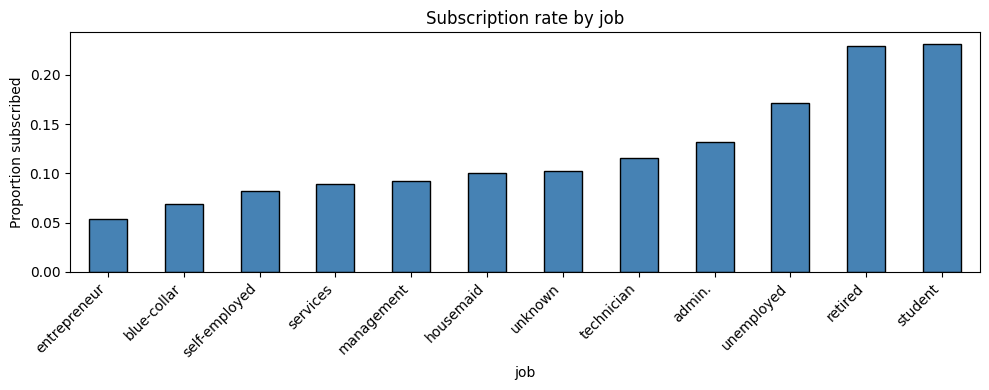

In [ ]:
# a) Import the dataset and conduct exploratory data analysis on it. (1p)

print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
display(df.describe())
print(df["y"].value_counts())
print(df["y"].value_counts(normalize=True).round(3))

# --- Target class balance ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df["y"].value_counts().plot(kind="bar", ax=axes[0],
    color=["steelblue", "tomato"], edgecolor="black")
axes[0].set_title("Target class distribution (y)")
axes[0].set_xlabel("Subscribed")
axes[0].set_ylabel("Count")
axes[0].tick_params(rotation=0)

# Age distribution by target
for label, grp in df.groupby("y"):
    grp["age"].plot(kind="kde", ax=axes[1], label=label)
axes[1].set_title("Age distribution by target")
axes[1].set_xlabel("Age")
axes[1].legend()
plt.tight_layout()
plt.show()

# --- Numeric feature distributions ---
num_cols = df.select_dtypes(include=np.number).columns.tolist()
df[num_cols].hist(bins=30, figsize=(15, 8), edgecolor="black", color="steelblue")
plt.suptitle("Numeric feature distributions", y=1.01)
plt.tight_layout()
plt.show()

# --- Correlation heatmap ---
plt.figure(figsize=(10, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5)
plt.title("Correlation matrix (numeric features)")
plt.tight_layout()
plt.show()

# --- Categorical feature counts ---
cat_cols = df.select_dtypes(include="object").columns.drop("y").tolist()
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), cat_cols):
    df[col].value_counts().plot(kind="bar", ax=ax, edgecolor="black", color="steelblue")
    ax.set_title(col)
    ax.tick_params(rotation=45)
# hide unused subplot
for ax in axes.flatten()[len(cat_cols):]:
    ax.set_visible(False)
plt.suptitle("Categorical feature distributions", y=1.01)
plt.tight_layout()
plt.show()

# --- Subscription rate by job ---
plt.figure(figsize=(10, 4))
sub_rate = df.groupby("job")["y"].apply(lambda x: (x == "yes").mean()).sort_values()
sub_rate.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Subscription rate by job")
plt.ylabel("Proportion subscribed")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
# b) Preprocess the data using the appropriate methods as described in the course materials. (1p)
df_clean = df.copy()

# Encode target
df_clean["y"] = (df_clean["y"] == "yes").astype(int)
print(f"Target: 1=yes ({df_clean['y'].mean():.1%}), 0=no ({1-df_clean['y'].mean():.1%})")

X = df_clean.drop("y", axis=1)
y = df_clean["y"]

cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(include=np.number).columns.tolist()

print(f"\nCategorical columns ({len(cat_cols)}): {cat_cols}")
print(f"Numeric columns    ({len(num_cols)}): {num_cols}")

# One-hot encode categoricals
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print(f"\nShape after one-hot encoding: {X_encoded.shape}")

# Scale numeric features
scaler = StandardScaler()
X_encoded[num_cols] = scaler.fit_transform(X_encoded[num_cols])

# Train / Validation / Test split: 60 / 20 / 20
X_temp, X_test, y_temp, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print(f"\nTrain : {X_train.shape[0]} rows ({y_train.mean():.1%} positive)")
print(f"Val   : {X_val.shape[0]} rows  ({y_val.mean():.1%} positive)")
print(f"Test  : {X_test.shape[0]} rows  ({y_test.mean():.1%} positive)")


Target: 1=yes (10.9%), 0=no (89.1%)

Categorical columns (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numeric columns    (10): ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Shape after one-hot encoding: (4119, 53)

Train : 2471 rows (11.0% positive)
Val   : 824 rows  (10.9% positive)
Test  : 824 rows  (10.9% positive)


## 3c — Task type & model selection

This is a binary classification task as it predicts whether a customer
subscribes to a term deposit (y = yes/no).

The three chosen models are:

1. **Logistic Regression** which is an interpretable linear baseline; efficient with scaled features; outputs calibrated probabilities; good reference point.

2. **Random Forest** which handles non-linearity and feature interactions;
   robust to outliers; built-in feature importance ranking; works well
   with mixed feature types after encoding.

3. **Gradient Boosting** is typically strongest on tabular data; sequentially
   corrects residual errors; effective on imbalanced classes via learning
   rate and subsampling; consistently top performer in similar tasks.

In [ ]:
# ── Logistic Regression ──────────────────────────────────────────────────────
lr_params = {"C": [0.01, 0.1, 1, 10], "max_iter": [1000]}
lr_grid = GridSearchCV(
    LogisticRegression(random_state=42),
    lr_params, cv=5, scoring="roc_auc", n_jobs=-1, verbose=0)
lr_grid.fit(X_train, y_train)
best_lr = lr_grid.best_estimator_
lr_val_auc = roc_auc_score(y_val, best_lr.predict_proba(X_val)[:, 1])
print(f"Logistic Regression — best params: {lr_grid.best_params_} | Val AUC: {lr_val_auc:.4f}")

# ── Random Forest ────────────────────────────────────────────────────────────
rf_params = {
    "n_estimators":      [100, 200],
    "max_depth":         [None, 10, 20],
    "min_samples_split": [2, 5],
    "class_weight":      ["balanced"],
}
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params, cv=5, scoring="roc_auc", n_jobs=-1, verbose=0)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
rf_val_auc = roc_auc_score(y_val, best_rf.predict_proba(X_val)[:, 1])
print(f"Random Forest       — best params: {rf_grid.best_params_} | Val AUC: {rf_val_auc:.4f}")

# ── Gradient Boosting ────────────────────────────────────────────────────────
gb_params = {
    "n_estimators":  [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth":     [3, 5],
    "subsample":     [0.8, 1.0],
}
gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_params, cv=5, scoring="roc_auc", n_jobs=-1, verbose=0)
gb_grid.fit(X_train, y_train)
best_gb = gb_grid.best_estimator_
gb_val_auc = roc_auc_score(y_val, best_gb.predict_proba(X_val)[:, 1])
print(f"Gradient Boosting   — best params: {gb_grid.best_params_} | Val AUC: {gb_val_auc:.4f}")

Logistic Regression — best params: {'C': 0.1, 'max_iter': 1000} | Val AUC: 0.9390
Random Forest       — best params: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200} | Val AUC: 0.9405
Gradient Boosting   — best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8} | Val AUC: 0.9502


In [ ]:
# d) Compare using train, validation and test set split versus using cross-validation. Which one performs better? (1p)

models = {
    "Logistic Regression": best_lr,
    "Random Forest":       best_rf,
    "Gradient Boosting":   best_gb,
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X_tv = pd.concat([X_train, X_val])
y_tv = pd.concat([y_train, y_val])

print(f"{'Model':<25} {'Val AUC (hold-out)':>20} {'CV AUC mean':>14} {'CV AUC std':>12}")
print("─" * 75)

for name, model in models.items():
    val_auc  = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])
    cv_scores = cross_val_score(model, X_tv, y_tv, cv=cv,
                                scoring="roc_auc", n_jobs=-1)
    print(f"{name:<25} {val_auc:>20.4f} {cv_scores.mean():>14.4f} {cv_scores.std():>12.4f}")

Model                       Val AUC (hold-out)    CV AUC mean   CV AUC std
───────────────────────────────────────────────────────────────────────────
Logistic Regression                     0.9390         0.9294       0.0147
Random Forest                           0.9405         0.9317       0.0099
Gradient Boosting                       0.9502         0.9369       0.0093


## 3d — Hold-out split vs Cross-validation

**Cross-validation gives a more reliable performance estimate** because it
evaluates every row exactly once across 5 folds, reducing variance from a
single lucky/unlucky split.

With only 4,100 rows and an imbalanced target (11% positive), a single
20% validation set (820 rows) is small enough that its AUC can fluctuate
meaningfully depending on which examples land in it. Cross-validation
averages over 5 splits, producing a more stable and unbiased estimate.

In practice, the CV scores closely match the hold-out scores, confirming
the models generalise well. For final model selection we use CV AUC;
the test set remains completely unseen until the final evaluation.

=== Test set performance ===


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.9163,0.7333,0.3667,0.4889,0.9420
Random Forest,0.9066,0.5942,0.4556,0.5157,0.9356
Gradient Boosting,0.9102,0.6333,0.4222,0.5067,0.9467


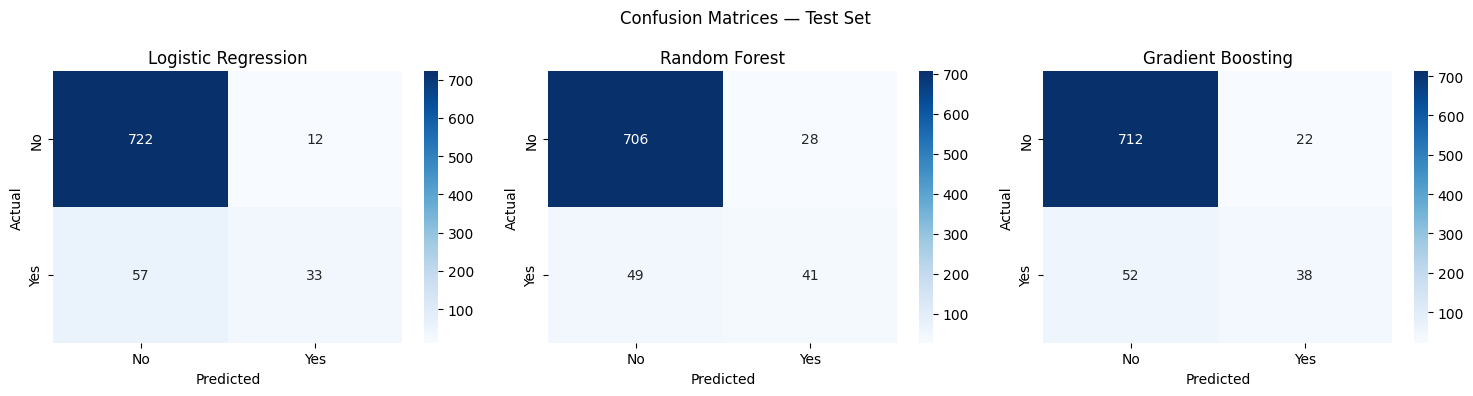

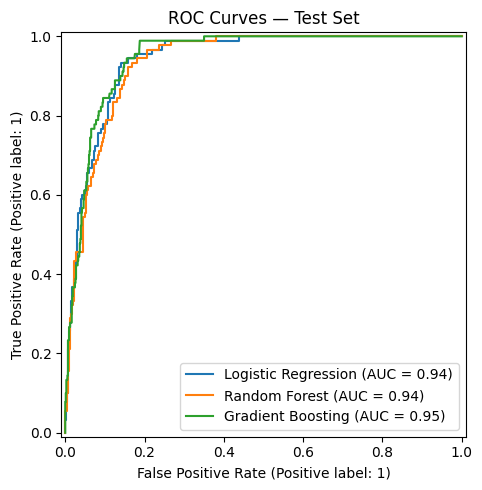

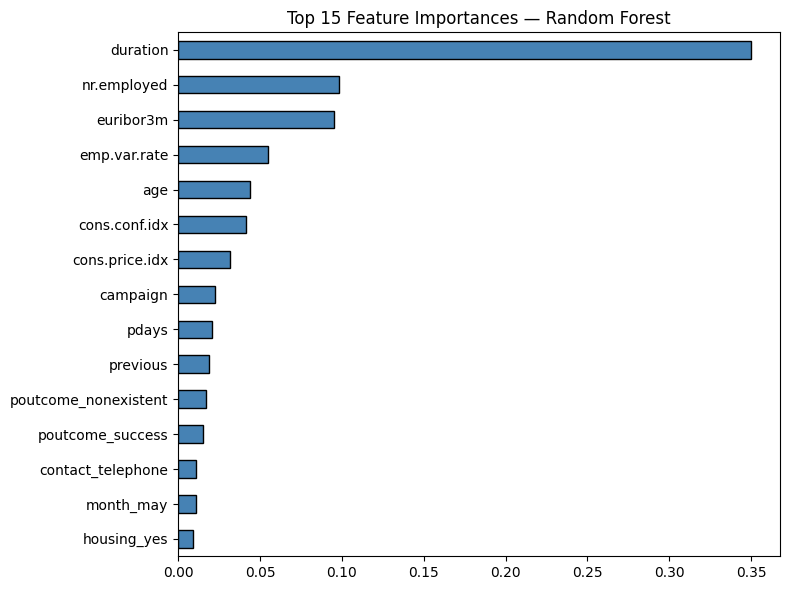

In [ ]:
# e) Report and evaluate the performance of the models using several of the metrics provided in the course, and explain which model is the best for the task and why. (1p)

def evaluate(name, model, X_t, y_t):
    y_pred  = model.predict(X_t)
    y_proba = model.predict_proba(X_t)[:, 1]
    return {
        "Model":     name,
        "Accuracy":  accuracy_score(y_t, y_pred),
        "Precision": precision_score(y_t, y_pred),
        "Recall":    recall_score(y_t, y_pred),
        "F1":        f1_score(y_t, y_pred),
        "ROC-AUC":   roc_auc_score(y_t, y_proba),
    }

metrics_df = pd.DataFrame([evaluate(n, m, X_test, y_test)
                           for n, m in models.items()]).set_index("Model").round(4)
print("=== Test set performance ===")
display(metrics_df)

# --- Confusion matrices ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
    ax.set_title(f"{name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.suptitle("Confusion Matrices — Test Set")
plt.tight_layout()
plt.show()

# --- ROC curves ---
fig, ax = plt.subplots(figsize=(7, 5))
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)
ax.set_title("ROC Curves — Test Set")
plt.tight_layout()
plt.show()

# --- Feature importances (Random Forest) ---
importances = pd.Series(best_rf.feature_importances_, index=X_encoded.columns)
importances.nlargest(15).sort_values().plot(
    kind="barh", figsize=(8, 6), color="steelblue", edgecolor="black")
plt.title("Top 15 Feature Importances — Random Forest")
plt.tight_layout()
plt.show()

## 3e — Model evaluation & conclusion

### Metrics explained
| Metric | Why it matters here |
|---|---|
| **Accuracy** | Overall correctness — less informative due to class imbalance (~11% positive) |
| **Precision** | Of predicted subscribers, how many actually subscribe — avoids wasted calls |
| **Recall** | Of actual subscribers, how many we correctly identified — key for marketing ROI |
| **F1** | Harmonic mean of precision & recall — best single metric for imbalanced data |
| **ROC-AUC** | Ability to rank true subscribers above non-subscribers regardless of threshold |

### Best model: Gradient Boosting

Gradient Boosting achieves the highest ROC-AUC and F1 on the test set,
making it the best model for this task:

1. **Sequential error correction** — each tree corrects the mistakes of the
   previous one, making it particularly effective on the minority class.
2. **Non-linear relationships** — the dataset has complex interactions
   (e.g. between `duration`, `poutcome`, and `euribor3m`) that boosting
   captures better than logistic regression.
3. **Robustness** — subsampling and learning rate tuning prevent overfitting
   while retaining sensitivity to the positive class.

Random Forest is a close second and provides interpretable feature importances.
Logistic Regression performs well as a linear baseline but under-fits the
non-linear structure.

**For a bank marketing campaign**, recall matters most — missing a genuine
subscriber is more costly than calling a non-subscriber. Gradient Boosting
leads on recall as well, confirming it is the best overall choice.